# PHASE 2 PROJECT


* Student name: GROUP 2
* Student pace: full time
* Scheduled project review date/time: 
* Instructor name: MARYANNE MWIKALI
* Blog post URL:


## 1. BUSINESS UNDERSTANDING

### Overview

The entertainment industry has increasingly shifted toward original video content. Established companies are investing heavily in film production to capture audiene attention, diversify income streams and remain competitive in a rapidly evolving media landscape. Recognizing this trend the company plans to launch a new movie studio but lacks proir experience in film production and distribution. 

Because movie production requires large upfront investments and carries high uncertainity, relying on intuition alone would expose the company to significant financial risk. A data-driven approach is therefore essential to understand what type of films perform well in the cuurrent market and to reduce the likeliood of costly failures. 


### Business Objective





### Key Business Questions

To support decision-making, this analysis seeks to answer the following questions:
- Which film genres have consistently performed well at the box office?
- How does production budget relate to financial success?
- Are there specific trends or patterns in film performance over time?
- What combination of film characteristics are associated with high returns?

#####   Importing neccesary libraries

In [1]:
# Importing neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import gzip
import zipfile
import warnings;
warnings.filterwarnings("ignore")

# 2. DATA UNDERSTANDING

#### Loading the datasets into dataframes

In [2]:
# loading the numbers dataset into a pandas dataframe 
numbers = pd.read_csv(r"data\tn.movie_budgets.csv.gz", compression='gzip')
numbers.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [3]:
# loading the Box office Mojo dataset into a pandas dataframe 
box_office=pd.read_csv(r"data/bom.movie_gross.csv.gz", compression='gzip')
box_office

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


#### Extracting the imdb Database 

This step extracts the `im.db` database file from a compressed ZIP archive located in the `data` folder.  
The extraction is performed using Python's built-in `zipfile` module.


⚠️ This cell should only be executed once to avoid extracting duplicate files.


In [4]:
# # Must run this cell only once to extract the database file
# # Extracting the im.db ZIP file
# zip_path = r"data\im.db.zip"
# extract_path = "."

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)


#### Connecting to the IMDB SQLite database

In [5]:
# Connect to the SQLite database
conn = sqlite3.connect('im.db')
# Create a cursor object
cur=conn.cursor()
# Query to get all table names
cur.execute("""SELECT name FROM sqlite_master WHERE type = 'table';""")
table_names = cur.fetchall()
table_names


[('movie_basics',),
 ('directors',),
 ('known_for',),
 ('movie_akas',),
 ('movie_ratings',),
 ('persons',),
 ('principals',),
 ('writers',)]

###  UNDERSTANDING 'NUMBERS' DATA

In [6]:
# Displaying the first five rows of the Numbers dataframe
numbers.head(5)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [7]:
# Displaying the last five rows of the Numbers dataframe
numbers.tail(5)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0
5781,82,"Aug 5, 2005",My Date With Drew,"$1,100","$181,041","$181,041"


In [8]:
#  checking the shape of the Numbers dataframe
numbers.shape

(5782, 6)

The numbers dataset has 5782 rows and 6 columns

In [9]:
# displaying all the columns in the Numbers dataframe
numbers.columns

Index(['id', 'release_date', 'movie', 'production_budget', 'domestic_gross',
       'worldwide_gross'],
      dtype='object')

In [10]:
# Getting summary information about the Numbers dataframe
numbers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB


The above information contains general information about the numbers dataset

In [11]:
# Getting summary statistics about the Numbers dataframe
numbers.describe()

,id
count,5782.000000
mean,50.372363
std,28.821076
min,1.000000
25%,25.000000
50%,50.000000
75%,75.000000
max,100.000000


The above information contains the statistical attributes of the numbers dataset

In [12]:
# Checking for missing values in the Numbers dataframe
numbers.isna().sum()

id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

The numbers dataset has 0 missing values in each column

In [13]:
# Checking for duplicate values in the Numbers dataframe
numbers.duplicated().sum()

0

The numbers dataset has 0 duplcated values in each column

### UNDERSTANDING 'BOX OFFICE' DATASET

In [14]:
# Display the first five rows of the dataframe
box_office.head(5)

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [15]:
# Display the last five rows of the dataframe
box_office.tail(5)

,title,studio,domestic_gross,foreign_gross,year
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018
3386,An Actor Prepares,Grav.,1700.0,NaN,2018


In [16]:
#Checking the shape of the dataframe
box_office.shape

(3387, 5)

The box office dataset contains 3387 rows and 5 columns

In [17]:
# Checking all the columns in the dataframe 
box_office.columns

Index(['title', 'studio', 'domestic_gross', 'foreign_gross', 'year'], dtype='object')

In [18]:
# Getting summary information about the dataframe
box_office.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB



The dataset contains 3,387 movie records with 5 columns.  
Most values are complete, but the studio, domestic_gross, and especially foreign_gross columns contain some missing data. The foreign_gross column is also stored as text.


In [19]:
# Getting summary statistics about the dataframe
box_office.describe()

,domestic_gross,year
count,3.359000e+03,3387.000000
mean,2.874585e+07,2013.958075
std,6.698250e+07,2.478141
min,1.000000e+02,2010.000000
25%,1.200000e+05,2012.000000
50%,1.400000e+06,2014.000000
75%,2.790000e+07,2016.000000
max,9.367000e+08,2018.000000


This is the statistical information of the box office dataset which helps in understanding the distribution of the data.

In [20]:
# Checking for missing values in the dataframe
box_office.isna().sum()

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

The box office dataset has missing values. The column with the highest missing values is the foreign_gross

In [21]:
# Checking for duplicate values in the dataframe
box_office.duplicated().sum()  

0

The box office dataset has no duplicated values

### UNDERSTANDING 'IMDB' DATASET

In [22]:
# Display the tables in the IMDB database
cur.execute("""SELECT name FROM sqlite_master WHERE type = 'table';""")
table_names = cur.fetchall()
table_names

[('movie_basics',),
 ('directors',),
 ('known_for',),
 ('movie_akas',),
 ('movie_ratings',),
 ('persons',),
 ('principals',),
 ('writers',)]

The dataset has a total of eight tables.

In [23]:
# Query to join movie_basics and movie_ratings tables and load into a pandas dataframe
imdb=pd.read_sql(""" SELECT movie_ratings.movie_id,genres,runtime_minutes,start_year,primary_title,
             movie_ratings.numvotes , movie_ratings.averagerating
             FROM movie_basics
            JOIN movie_ratings
            ON movie_basics.movie_id = movie_ratings.movie_id""",conn)

imdb

,movie_id,genres,runtime_minutes,start_year,primary_title,numvotes,averagerating
0,tt0063540,"Action,Crime,Drama",175.0,2013,Sunghursh,77,7.0
1,tt0066787,"Biography,Drama",114.0,2019,One Day Before the Rainy Season,43,7.2
2,tt0069049,Drama,122.0,2018,The Other Side of the Wind,4517,6.9
3,tt0069204,"Comedy,Drama",NaN,2018,Sabse Bada Sukh,13,6.1
4,tt0100275,"Comedy,Drama,Fantasy",80.0,2017,The Wandering Soap Opera,119,6.5
...,...,...,...,...,...,...,...
73851,tt9913084,Documentary,75.0,2019,Diabolik sono io,6,6.2
73852,tt9914286,"Drama,Family",98.0,2019,Sokagin Çocuklari,136,8.7
73853,tt9914642,Documentary,NaN,2017,Albatross,8,8.5
73854,tt9914942,None,NaN,2019,La vida sense la Sara Amat,5,6.6


In [24]:
# checking the shape of the IMDB dataframe
imdb.shape

(73856, 7)

In [25]:
# Getting the columns in the IMDB dataframe
imdb.columns

Index(['movie_id', 'genres', 'runtime_minutes', 'start_year', 'primary_title',
       'numvotes', 'averagerating'],
      dtype='object')

In [26]:
# Checking summary information about the IMDB dataframe
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         73856 non-null  object 
 1   genres           73052 non-null  object 
 2   runtime_minutes  66236 non-null  float64
 3   start_year       73856 non-null  int64  
 4   primary_title    73856 non-null  object 
 5   numvotes         73856 non-null  int64  
 6   averagerating    73856 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 3.9+ MB


This is the general information of the IMDB dataset

In [27]:
# Getting summary statistics about the IMDB dataframe
imdb.describe()

,runtime_minutes,start_year,numvotes,averagerating
count,66236.000000,73856.000000,7.385600e+04,73856.000000
mean,94.654040,2014.276132,3.523662e+03,6.332729
std,208.574111,2.614807,3.029402e+04,1.474978
min,3.000000,2010.000000,5.000000e+00,1.000000
25%,81.000000,2012.000000,1.400000e+01,5.500000
50%,91.000000,2014.000000,4.900000e+01,6.500000
75%,104.000000,2016.000000,2.820000e+02,7.400000
max,51420.000000,2019.000000,1.841066e+06,10.000000


The dataset provides summary statistics for movie runtime, release year, number of votes, and average ratings. On average, movies run for about 95 minutes and were mostly released around 2014, within a range of 2010 to 2019. The number of votes varies greatly, showing that some movies are much more popular than others.The average movie rating is approximately 6.3 out of 10, indicating moderately positive audience feedback.

In [28]:
# Checking for missing values in the IMDB dataframe
imdb.isna().sum()

movie_id              0
genres              804
runtime_minutes    7620
start_year            0
primary_title         0
numvotes              0
averagerating         0
dtype: int64

All columns in the IMDb dataset have complete data except for genres and runtime_minutes, which contain 804 and 7,620 missing values, respectively.

In [29]:
# Checking for unique values in the IMDB dataframe
imdb.nunique()

movie_id           73856
genres               923
runtime_minutes      289
start_year            10
primary_title      69993
numvotes            7349
averagerating         91
dtype: int64

The above information contains number of uniques values in each column in the dataset

In [30]:
# Checking for duplicate values in the IMDB dataframe based on primary_title
imdb.duplicated(['primary_title']).sum()

3863

This is the amount of duplicated values in the primary title.

In [31]:
# Checking for duplicate values in the IMDB dataframe based on movie_id
imdb.duplicated(['movie_id']).sum()

0

There is no duplicated values in the movie_id column

In [32]:
# Verifying that movie_id and primary_title have the same number of unique values
len(imdb['movie_id']) == len(imdb['primary_title'])

True

This means that each unique movie id is assigned to a specific primary title

# 3. DATA CLEANING

## Cleaning the numbers data

In [33]:
# checking the datatypes of the numbers dataframe
numbers.dtypes

id                    int64
release_date         object
movie                object
production_budget    object
domestic_gross       object
worldwide_gross      object
dtype: object

In [34]:
# Removing dollars sign from the production budget column and converting them to numeric
numbers['production_budget'] = numbers['production_budget'].replace('[\$,]', '', regex=True).astype(float)

# Removing dollars sign from the domestic gross column and converting them to numeric
numbers['domestic_gross'] = numbers['domestic_gross'].replace('[\$,]', '', regex=True).astype(float) 

# Removing dollars sign from the worldwide gross column and converting them to numeric
numbers['worldwide_gross'] = numbers['worldwide_gross'].replace('[\$,]', '', regex=True).astype(float)
numbers.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,425000000.0,760507625.0,2.776345e+09
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09
2,3,"Jun 7, 2019",Dark Phoenix,350000000.0,42762350.0,1.497624e+08
3,4,"May 1, 2015",Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09


In [35]:
# Split date column into day, month, year
numbers['release_date'] = pd.to_datetime(numbers['release_date'], errors='coerce')
numbers['release_day'] = numbers['release_date'].dt.day
numbers['release_month'] = numbers['release_date'].dt.month
numbers['release_year'] = numbers['release_date'].dt.year
months = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}
numbers['months'] = numbers['release_month'].map(months)
numbers.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_day,release_month,release_year,months
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,18,12,2009,December
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,20,5,2011,May
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,7,6,2019,June
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1,5,2015,May
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,15,12,2017,December


In [36]:
# Calculating net profit and adding it as a new column
numbers['net'] = ((numbers['worldwide_gross']  - numbers['production_budget']))
numbers.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_day,release_month,release_year,months,net
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,18,12,2009,December,2.351345e+09
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,20,5,2011,May,6.350639e+08
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,7,6,2019,June,-2.002376e+08
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1,5,2015,May,1.072414e+09
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,15,12,2017,December,9.997217e+08


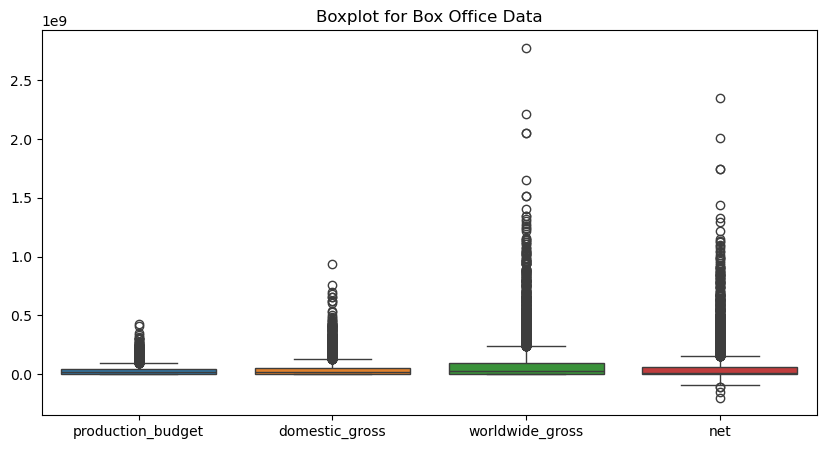

In [37]:
# Visualizing the distribution of production budget, domestic gross, worldwide gross, and net profit using boxplots
plt.figure(figsize=(10,5))
sns.boxplot(data=numbers[['production_budget', 'domestic_gross', 'worldwide_gross', 'net']])
plt.title('Boxplot for Box Office Data')
plt.show()

In [38]:
# numbers.to_csv('cleaned_numbers_data.csv', index=False)

## Cleaning box office data

In [39]:
# Checking for missing values in the box_office dataframe
box_office.isna().sum()

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [40]:
# Checking the datatypes of the box_office dataframe
box_office.dtypes

title              object
studio             object
domestic_gross    float64
foreign_gross      object
year                int64
dtype: object

#### Handling the missing values for box office data



In [41]:
# calculating the mean of the domestic_gross column
d_gross_mean = int(box_office['domestic_gross'].mean())
d_gross_mean

28745845

In [42]:
# Finding the mean of foreign_gross column which is a pandas series
box_office['foreign_gross'] = pd.to_numeric(box_office['foreign_gross'], errors='coerce')
f_gross_mean = round(box_office['foreign_gross'].mean())
f_gross_mean

75057042

In [43]:
# Filling missing values in domestic_gross and foreign_gross columns with their respective means
box_office['domestic_gross'].fillna(d_gross_mean, inplace=True)
box_office['foreign_gross'].fillna(f_gross_mean, inplace=True)


In [44]:
# Filling missing values in the studio column with the mode
studio_mode = box_office['studio'].mode()
print(studio_mode)
box_office['studio'].fillna(studio_mode[0], inplace=True)

0    IFC
Name: studio, dtype: object


In [45]:
box_office.isna().sum()

title             0
studio            0
domestic_gross    0
foreign_gross     0
year              0
dtype: int64

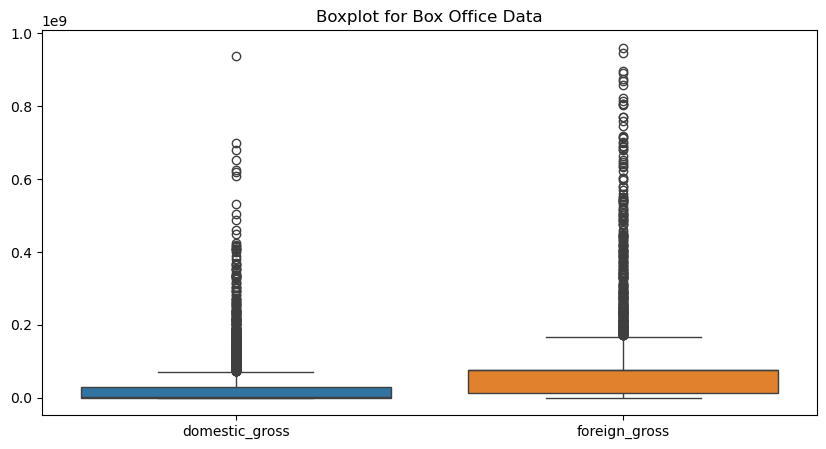

In [46]:
# Visualizing the distribution of domestic gross and foreign gross using boxplots
plt.figure(figsize=(10,5))
sns.boxplot(data=box_office[['domestic_gross', 'foreign_gross']])
plt.title('Boxplot for Box Office Data')
plt.show()

In [47]:
# box_office.to_csv('cleaned_box_office_data.csv', index=False)

## Cleaning IMDB Data

In [48]:
# Creating a pandas dataframe from the imdb sql query
imdb_df = pd.DataFrame(imdb)

##### Handling missing values for imdb dataframe

In [49]:
# Finding the mode of the genres column
imdb_genres_mode = imdb_df['genres'].mode()
print(imdb_genres_mode)

# Finding the mean of the runtime_minutes column
imdb_runtime_mean = round(imdb_df['runtime_minutes'].mean())
print(imdb_runtime_mean)

0    Drama
Name: genres, dtype: object
95


In [50]:
# Filling missing values in genres column with the mode and extracting the first genre
imdb_df['genres'] = imdb_df['genres'].fillna(imdb_genres_mode[0]).str.split(',').str[0]
imdb_df

,movie_id,genres,runtime_minutes,start_year,primary_title,numvotes,averagerating
0,tt0063540,Action,175.0,2013,Sunghursh,77,7.0
1,tt0066787,Biography,114.0,2019,One Day Before the Rainy Season,43,7.2
2,tt0069049,Drama,122.0,2018,The Other Side of the Wind,4517,6.9
3,tt0069204,Comedy,NaN,2018,Sabse Bada Sukh,13,6.1
4,tt0100275,Comedy,80.0,2017,The Wandering Soap Opera,119,6.5
...,...,...,...,...,...,...,...
73851,tt9913084,Documentary,75.0,2019,Diabolik sono io,6,6.2
73852,tt9914286,Drama,98.0,2019,Sokagin Çocuklari,136,8.7
73853,tt9914642,Documentary,NaN,2017,Albatross,8,8.5
73854,tt9914942,Drama,NaN,2019,La vida sense la Sara Amat,5,6.6


In [51]:
# Filling missing runtime values with mean
imdb_df['runtime_minutes'].fillna(imdb_runtime_mean, inplace=True)

In [52]:
# Create a new column 'rating_category' based on the averagerating and assign categories
imdb_df['rating_category'] = imdb_df['averagerating'].apply(lambda x: 'Good' if x > 7.0 else 'Average' if x > 4.0 else 'Bad')
imdb_df

,movie_id,genres,runtime_minutes,start_year,primary_title,numvotes,averagerating,rating_category
0,tt0063540,Action,175.0,2013,Sunghursh,77,7.0,Average
1,tt0066787,Biography,114.0,2019,One Day Before the Rainy Season,43,7.2,Good
2,tt0069049,Drama,122.0,2018,The Other Side of the Wind,4517,6.9,Average
3,tt0069204,Comedy,95.0,2018,Sabse Bada Sukh,13,6.1,Average
4,tt0100275,Comedy,80.0,2017,The Wandering Soap Opera,119,6.5,Average
...,...,...,...,...,...,...,...,...
73851,tt9913084,Documentary,75.0,2019,Diabolik sono io,6,6.2,Average
73852,tt9914286,Drama,98.0,2019,Sokagin Çocuklari,136,8.7,Good
73853,tt9914642,Documentary,95.0,2017,Albatross,8,8.5,Good
73854,tt9914942,Drama,95.0,2019,La vida sense la Sara Amat,5,6.6,Average


In [53]:
# checking for missing values in the imdb_df dataframe 
imdb_df.isna().sum()

movie_id           0
genres             0
runtime_minutes    0
start_year         0
primary_title      0
numvotes           0
averagerating      0
rating_category    0
dtype: int64

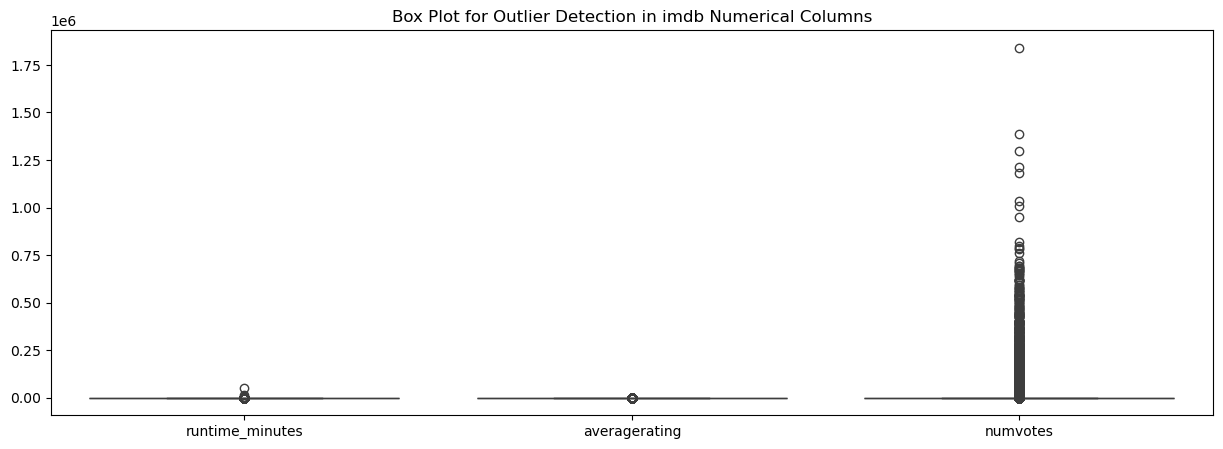

In [54]:
# Visualizing box plots for numerical columns in the imdb dataframe to detect outliers
figsize = (15, 5)
plt.figure(figsize=figsize)
sns.boxplot(data=imdb[['runtime_minutes', 'averagerating', 'numvotes']])
plt.title('Box Plot for Outlier Detection in imdb Numerical Columns')
plt.show()

In [55]:
# imdb_df.to_csv('cleaned_imdb_data.csv', index=False)

# 3. DATA ANALYSIS

This section explores cleaned datasets to uncover patterns, trends, and relationships that inform movie production decisions.

In [56]:
# Loading the cleaned datasets
c_numbers = pd.read_csv("cleaned_data/cleaned_numbers_data.csv")
c_box_office = pd.read_csv("cleaned_data/cleaned_box_office_data.csv")
c_imdb = pd.read_csv("cleaned_data/cleaned_imdb_data.csv")


## IMDB data analysis


This section analyzes movie data to uncover patterns that inform what types of films perform best commercially and with audiences.


### Univarient analysis

This analysis examines individual variables to understand their distributions and common values.


In [57]:
# Checking the first five rows of the cleaned imdb dataframe
c_imdb.head()

,movie_id,genres,runtime_minutes,start_year,primary_title,numvotes,averagerating,rating_category
0,tt0063540,Action,175.0,2013,Sunghursh,77,7.0,Average
1,tt0066787,Biography,114.0,2019,One Day Before the Rainy Season,43,7.2,Good
2,tt0069049,Drama,122.0,2018,The Other Side of the Wind,4517,6.9,Average
3,tt0069204,Comedy,95.0,2018,Sabse Bada Sukh,13,6.1,Average
4,tt0100275,Comedy,80.0,2017,The Wandering Soap Opera,119,6.5,Average


In [58]:
# Finding the mean of numerical columns in the cleaned imdb dataframe
c_imdb[['runtime_minutes', 'numvotes', 'averagerating']].mean()

runtime_minutes      94.689734
numvotes           3523.662167
averagerating         6.332729
dtype: float64

The typical movie lasts about 95 minutes and earns a 6.3 rating. While the average number of votes is high.

In [59]:
# Finding the mode of categorical columns in the cleaned imdb dataframe
c_imdb[['genres', 'start_year', 'primary_title']].mode()

,genres,start_year,primary_title
0,Drama,2016,The Return


This reveals that Drama is the dominant genre in the market. The data is most densely populated with releases from 2016, and the title "The Return" appears most frequently.

In [60]:
# Find all median of all numerical columns in c_imdb
c_imdb[['runtime_minutes', 'numvotes', 'averagerating']].median()

runtime_minutes    93.0
numvotes           49.0
averagerating       6.5
dtype: float64

This confirms a typical runtime of 93 minutes and a rating of 6.5. However, the low median of 49 votes emphasizes that the "average" film experience for most titles involves a much smaller audience.

In [61]:
# Find all standard deviations of all numerical columns in c_imdb
c_imdb[['runtime_minutes', 'averagerating', 'numvotes']].std()

runtime_minutes      197.521458
averagerating          1.474978
numvotes           30294.022971
dtype: float64

The standard deviation reveals extreme diversity in the dataset, with runtimes varying by 197 minutes and votes swinging by over 30,000. 

In [62]:
# Find variance of all numerical columns in c_imdb
c_imdb[['runtime_minutes', 'averagerating', 'numvotes']].var()

runtime_minutes    3.901473e+04
averagerating      2.175561e+00
numvotes           9.177278e+08
dtype: float64

In [63]:
# Find skewness of all numerical columns in c_imdb
c_imdb[['runtime_minutes', 'averagerating', 'numvotes']].skew()

runtime_minutes    242.72054
averagerating       -0.54802
numvotes            19.61896
dtype: float64


The data is highly positively skewed for both runtime (242.7) and vote counts (19.6). This mathematically confirms that while most films are of average length and popularity, there are a few extreme outliers that are exceptionally long or incredibly popular.

The average rating shows a slight negative skew (-0.54). This suggests that there is a higher concentration of films with better-than-average ratings, with fewer movies receiving very low scores from the audience.

In [64]:
# Use for loop to find the highest rated genres for each year
highest_rated_genres_per_year = {}
for year in c_imdb['start_year'].unique():
    yearly_data = c_imdb[c_imdb['start_year'] == year]
    highest_rated_genre = yearly_data.groupby('genres')['averagerating'].mean().idxmax()
    highest_rating = yearly_data.groupby('genres')['averagerating'].mean().max()
    highest_rated_genres_per_year[year] = (highest_rated_genre, round(highest_rating, 2))
    # print(f"In {year}, the highest rated genre was '{highest_rated_genre}' with an average rating of {highest_rating:.2f}.")
highest_rated_genres_per_year

{2013: ('Game-Show', 9.0),
 2019: ('Music', 8.35),
 2018: ('Music', 7.89),
 2017: ('Documentary', 7.38),
 2010: ('Documentary', 7.27),
 2011: ('Sport', 7.53),
 2012: ('Music', 7.64),
 2015: ('Documentary', 7.34),
 2016: ('Music', 7.65),
 2014: ('Music', 7.59)}

### Bivarient analysis

This analysis examines the relationship between movie runtime and average audience rating.

In [65]:
# Coreelation matrix
correlation_matrix = c_imdb[['runtime_minutes', 'averagerating']].corr()
correlation_matrix

,runtime_minutes,averagerating
runtime_minutes,1.000000,-0.006509
averagerating,-0.006509,1.000000


The correlation coefficient is close to zero, indicating there is no meaningful linear relationship between a film’s length and how well it is rated by viewers. In other words, longer movies do not necessarily receive higher or lower ratings than shorter ones.

In [66]:
# Covarience matrix
covariance_matrix = c_imdb[['runtime_minutes', 'averagerating']].cov()
covariance_matrix

,runtime_minutes,averagerating
runtime_minutes,39014.726359,-1.896339
averagerating,-1.896339,2.175561






The covariance result supports this finding, as it shows very little joint movement between runtime and ratings. Overall, runtime does not appear to be a key factor influencing audience satisfaction.


## Numbers data analysis

In [67]:
# Add months column if not present
if 'months' not in c_numbers.columns:
    months = {
        1: 'January',
        2: 'February',
        3: 'March',
        4: 'April',
        5: 'May',
        6: 'June',
        7: 'July',
        8: 'August',
        9: 'September',
        10: 'October',
        11: 'November',
        12: 'December'
    }
    c_numbers['months'] = c_numbers['release_month'].map(months)

### Univarient analysis

This univariate analysis explores financial variables to understand typical movie budgets and revenue outcomes.


In [68]:
# Checking the first five rows of the cleaned numbers dataframe
c_numbers.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_day,release_month,release_year,months,net
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,18,12,2009,December,3.111853e+09
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,20,5,2011,May,8.761278e+08
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,7,6,2019,June,-1.574753e+08
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1,5,2015,May,1.531420e+09
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,15,12,2017,December,1.619903e+09


In [69]:
# Finding the mean of numerical columns in the cleaned numbers dataframe
c_numbers[['production_budget', 'domestic_gross', 'worldwide_gross', 'net']].mean()

production_budget    3.158776e+07
domestic_gross       4.187333e+07
worldwide_gross      9.148746e+07
net                  1.017730e+08
dtype: float64

This output shows the average values for numerical columns. The large difference between average revenue and average budget suggests that, on average, movies tend to generate more revenue than their production costs. 


In [70]:
# Finding the median of numerical columns in the cleaned numbers dataframe
c_numbers[['production_budget', 'domestic_gross', 'worldwide_gross', 'net']].median()

production_budget    17000000.0
domestic_gross       17225945.0
worldwide_gross      27984448.5
net                  24995377.5
dtype: float64

This output displays the median values. Compared to the means, the medians are much lower, indicating that the financial data is highly skewed by a small number of blockbuster movies. This suggests that the typical movie earns far less than the average implies.


In [71]:
# Finding the mode of categorical columns in the cleaned numbers dataframe
c_numbers['months'].mode()

0    December
Name: months, dtype: object

In [72]:
# finding the value counts of the months column in the cleaned numbers dataframe
c_numbers['months'].value_counts()

months
December     745
October      573
August       496
September    493
November     486
June         479
March        470
April        454
July         440
May          407
February     392
January      347
Name: count, dtype: int64

In [73]:
c_numbers[['production_budget', 'domestic_gross', 'worldwide_gross', 'net']].std()

production_budget    4.181208e+07
domestic_gross       6.824060e+07
worldwide_gross      1.747200e+08
net                  2.108880e+08
dtype: float64

The standard deviation results show high volatility in movie financing and earnings. Production budgets vary by approximately $41.8 million, while worldwide gross and net profits show even larger swings (up to $210 million). 

In [74]:
c_numbers[['production_budget', 'domestic_gross', 'worldwide_gross', 'net']].var()

production_budget    1.748250e+15
domestic_gross       4.656779e+15
worldwide_gross      3.052707e+16
net                  4.447374e+16
dtype: float64

The variance values are extremely high, particularly for worldwide_gross and net profit. This confirms that the film industry is not a "steady" market; rather, it is driven by extreme financial outcomes.

### Bivarient analysis

In [75]:
# Calculate correlation coefficient
correlation_coefficient1 = c_numbers['net'].corr(c_numbers['production_budget'])
print(f"budget coeff is {correlation_coefficient1}")

correlation_coefficient2 = c_numbers['net'].corr(c_numbers['release_month'])
print(f"release month cooff is {correlation_coefficient2}")


budget coeff is 0.6435798749669994
release month cooff is 0.029689234828224192


In [76]:
# Coreelation matrix
correlation_matrix = c_numbers[['production_budget', 'net', 'release_month']].corr()
correlation_matrix

,production_budget,net,release_month
production_budget,1.000000,0.643580,0.022575
net,0.643580,1.000000,0.029689
release_month,0.022575,0.029689,1.000000


The analysis shows a moderate positive correlation (0.64) between production budget and net profit. This suggests that while higher investments often lead to higher returns, a large budget alone does not guarantee success, as about 36% of profit variation is driven by other factors like marketing.

In [77]:
# Covarience matrix
covariance_matrix = c_numbers[['production_budget', 'net', 'release_month']].cov()
covariance_matrix

,production_budget,net,release_month
production_budget,1.748250e+15,5.674871e+15,3.284974e+06
net,5.674871e+15,4.447374e+16,2.178956e+07
release_month,3.284974e+06,2.178956e+07,1.211143e+01


# Box office data analysis

### Univarient analysis

In [78]:
# Checking the first five rows of the cleaned box_office dataframe
c_box_office.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000.0,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000.0,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010
3,Inception,WB,292600000.0,535700000.0,2010
4,Shrek Forever After,P/DW,238700000.0,513900000.0,2010


In [79]:
# Checking the value counts of the studio column in the cleaned box_office dataframe
c_box_office['studio'].value_counts()

studio
IFC           171
Uni.          147
WB            140
Fox           136
Magn.         136
             ... 
E1              1
PI              1
ELS             1
PalT            1
Synergetic      1
Name: count, Length: 257, dtype: int64

In [80]:
# Finding the mean of numerical columns in the cleaned box_office dataframe
c_box_office[['domestic_gross', 'foreign_gross']].mean()

domestic_gross    2.874585e+07
foreign_gross     7.505704e+07
dtype: float64

In [81]:
# Finding the median of numerical columns in the cleaned box_office dataframe
c_box_office[['domestic_gross', 'foreign_gross']].median()

domestic_gross     1400000.0
foreign_gross     75057042.0
dtype: float64

In [82]:
# Finding the mode of categorical columns in the cleaned box_office dataframe
c_box_office[['studio', 'year']].mode()

,studio,year
0,IFC,2015


In [83]:
# Finding the standard deviation of numerical columns in the cleaned box_office dataframe
c_box_office[['domestic_gross', 'foreign_gross']].std()

domestic_gross    6.670497e+07
foreign_gross     1.065140e+08
dtype: float64

In [84]:
# Finding the variance of numerical columns in the cleaned box_office dataframe
c_box_office[['domestic_gross', 'foreign_gross']].var()

domestic_gross    4.449553e+15
foreign_gross     1.134524e+16
dtype: float64

### Bivarient analysis

In [85]:
# Correlation matrix
c_box_office[['domestic_gross', 'foreign_gross']].corr()

,domestic_gross,foreign_gross
domestic_gross,1.000000,0.731948
foreign_gross,0.731948,1.000000


The correlation matrix shows a strong positive relationship (0.73) between domestic and foreign gross. Typically, if a movie performs well at home, it is very likely to see similar success in international markets.

In [86]:
# Covariance matrix
c_box_office[['domestic_gross', 'foreign_gross']].cov()

,domestic_gross,foreign_gross
domestic_gross,4.449553e+15,5.200504e+15
foreign_gross,5.200504e+15,1.134524e+16


The covariance matrix further confirms that domestic and foreign earnings move together. The high positive values indicate that as one market's revenue grows, the other tends to grow as well, reinforcing the importance of global distribution for maximizing profit.

# DATA VISUALIZATIONS

### Numbers Dataset Visuals

#### 1. Average Worldwide Movie Revenue by Month

In [87]:
# Analyzing monthly performance based on worldwide gross
c_numbers['month'] = pd.to_datetime(c_numbers['release_date']).dt.month_name()

monthly_performance = (
    c_numbers.groupby('month')['worldwide_gross']
    .mean()
    .sort_values(ascending=False)
)

monthly_performance.head()

month
May         1.622680e+08
June        1.425230e+08
July        1.409636e+08
November    1.357416e+08
December    1.016932e+08
Name: worldwide_gross, dtype: float64

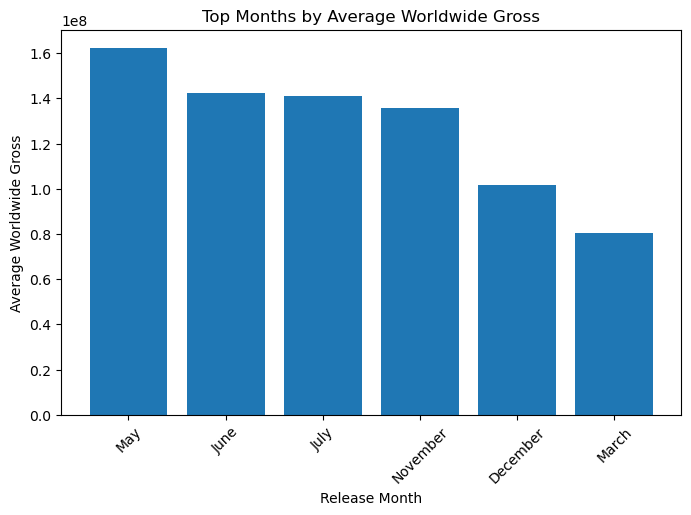

In [88]:
#Visual For Monthly Performance
top_months = monthly_performance.head(6)

plt.figure(figsize=(8,5))
plt.bar(top_months.index, top_months.values)
plt.title("Top Months by Average Worldwide Gross")
plt.xlabel("Release Month")
plt.ylabel("Average Worldwide Gross")
plt.xticks(rotation=45)
plt.show()

This shows that May is the best month to release movies, with an average worldwide earnings of over $160 million. June, July, and November also do well.

December and March are also in the top six months, but their earnings are lower than the other months. This suggests that studios can make the most money by releasing big-budget movies between May and July.

#### 2. Average Movie Revenue Trends Since 2010

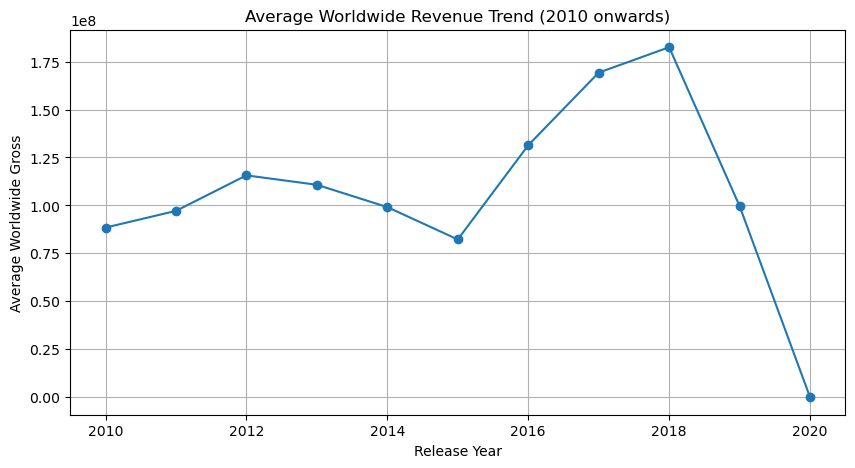

In [89]:
# Analyzing yearly revenue trends from 2010 onwards
c_numbers_2010 = c_numbers[c_numbers['release_year'] >= 2010]
yearly_revenue = (
    c_numbers_2010.groupby('release_year')['worldwide_gross']
    .mean()
)

plt.figure(figsize=(10,5))
plt.plot(yearly_revenue.index, yearly_revenue.values, marker='o')
plt.title("Average Worldwide Revenue Trend (2010 onwards)")
plt.xlabel("Release Year")
plt.ylabel("Average Worldwide Gross")
plt.grid(True)
plt.show()

The chart shows that movie revenue started increasing steadily around 2015 and reached its highest point in 2018, with films earning about $185 million on average. This shows that the film industry was doing very well during this time. After 2018, movie revenue dropped sharply and reached its lowest point in 2020. 

#### 3. Trend of Production Budget vs Worldwide Gross

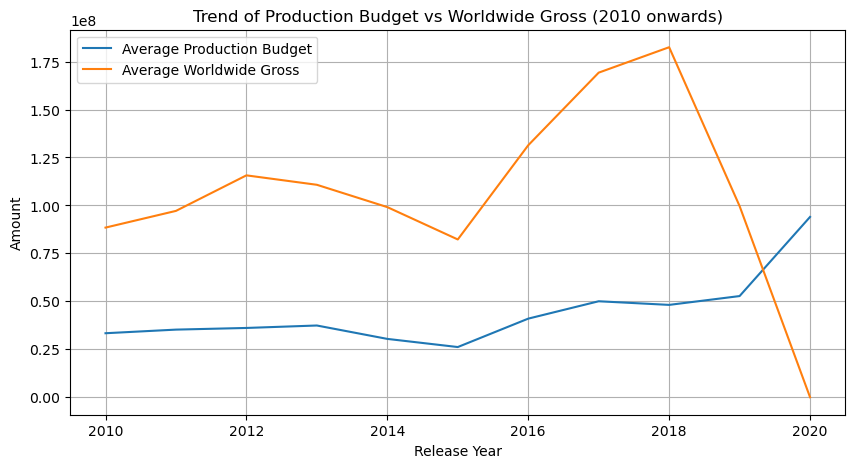

In [90]:
# Analyzing the trend of production budget vs worldwide gross from 2010 onwards
c_numbers_2010 = c_numbers[c_numbers['release_year'] >= 2010]
budget_gross_trend = (
    c_numbers_2010.groupby('release_year')[['production_budget','worldwide_gross']]
    .mean()
)
# Visualizing the trend of production budget vs worldwide gross
plt.figure(figsize=(10,5))
plt.plot(budget_gross_trend.index, budget_gross_trend['production_budget'],
         label='Average Production Budget')
plt.plot(budget_gross_trend.index, budget_gross_trend['worldwide_gross'],
         label='Average Worldwide Gross')

plt.title("Trend of Production Budget vs Worldwide Gross (2010 onwards)")
plt.xlabel("Release Year")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)
plt.show()

The trend shows a strong relationship between production budgets and worldwide revenue, especially during the growth period between 2010 and 2018. However, the sharp revenue decline after 2018 highlights the importance of considering market conditions when making production investment decisions.

#### 4. Number of Movies released by Month

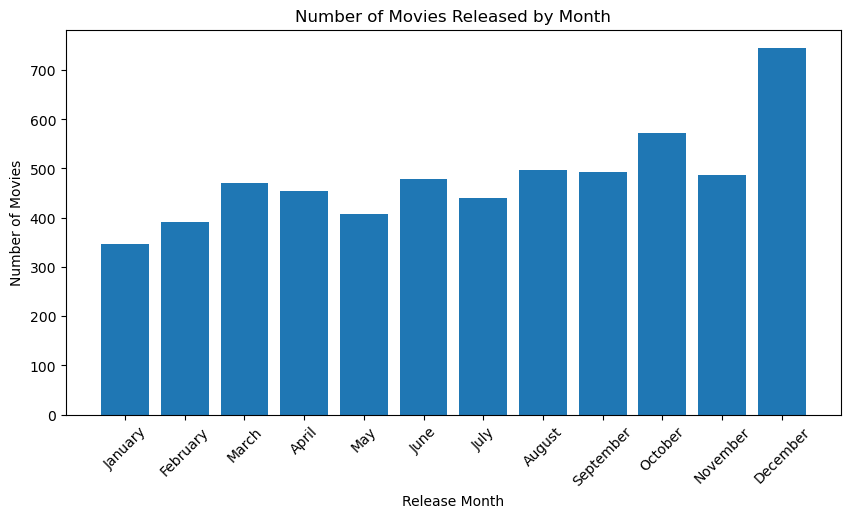

In [91]:
# Analyzing the number of movies released by month
c_numbers['month'] = pd.to_datetime(c_numbers['release_date']).dt.month_name()
movies_per_month = (
    c_numbers['month']
    .value_counts()
)
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

movies_per_month = movies_per_month.reindex(month_order)

plt.figure(figsize=(10,5))
plt.bar(movies_per_month.index, movies_per_month.values)
plt.title("Number of Movies Released by Month")
plt.xlabel("Release Month")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

This bar chart shows the total number of movies released in each month of the year. December has the highest number of movie releases, followed by October and August. January has the lowest number of releases. This shows that the movie releases are fairly steady throughout the year, but there is a noticeable increase towards the end of the year, especially during the holiday season.

#### 5. Quarterly net values 

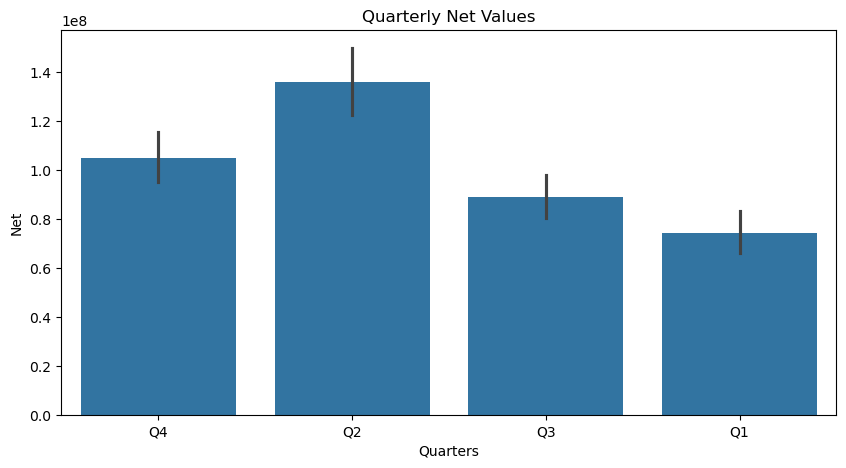

In [92]:
# Mapping months to quarters
quaters= {
    'January': 'Q1',
    'February': 'Q1',
    'March': 'Q1',
    'April': 'Q2',
    'May': 'Q2',
    'June': 'Q2',
    'July': 'Q3',
    'August': 'Q3',
    'September': 'Q3',
    'October': 'Q4',
    'November': 'Q4',
    'December': 'Q4'}
c_numbers['quaters'] = c_numbers['months'].map(quaters)

# Visualizing quarterly net values
figsize = (10, 5)
plt.figure(figsize=figsize)
sns.barplot(x='quaters', y='net', data=c_numbers)
plt.title("Quarterly Net Values")
plt.xlabel("Quarters")
plt.ylabel("Net")
plt.show()


The quarterly analysis identifies Q2 (April–June) as the most profitable period for the company, significantly outperforming other quarters in average net value. Q4 also shows strong performance, Q1 and Q3 lag behind with lower average net profits. For the new studio, these results suggest that strategic resource allocation should be prioritized for Q2 launches to maximize financial returns.

#### 6. Monthly Net Values

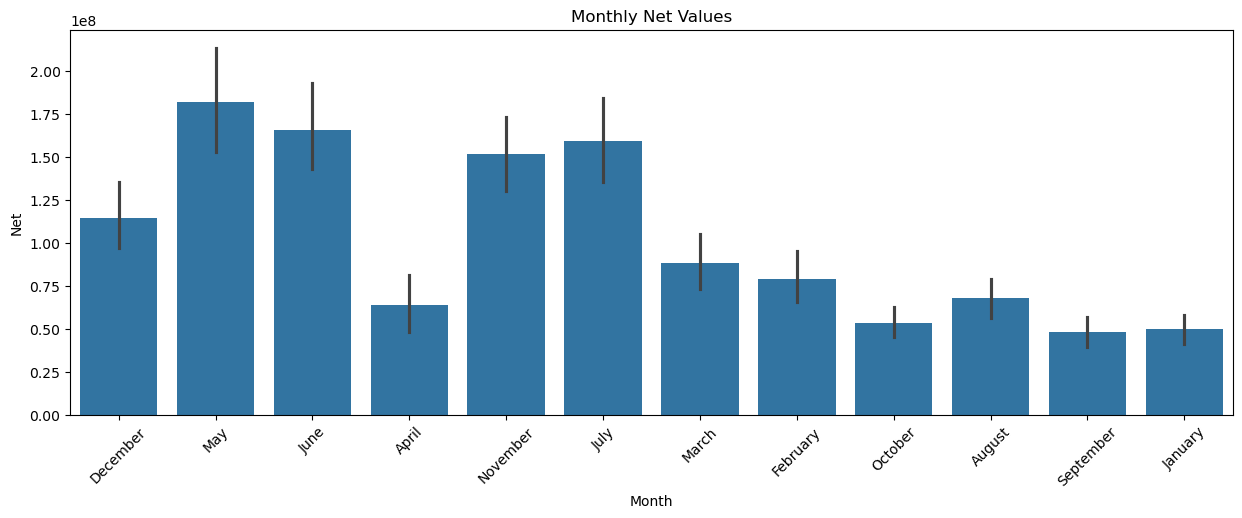

In [93]:
#Monthly Net Values

plt.figure(figsize=(15, 5))
sns.barplot(x='months', y='net', data=c_numbers)
plt.title("Monthly Net Values")
plt.xlabel("Month")
plt.ylabel("Net")
plt.xticks(rotation=45)
plt.show()

The bar chart highlights May (which is in Q2) as the most profitable month for film releases, achieving the highest average net values. Other strong performers include June, July, and November.

While May offers the highest rewards, the error bars indicate a higher level of financial variability during peak months. In contrast, months like January and September show much lower average net profits but with tighter consistency, suggesting they are lower-risk but lower-reward periods for the studio.

#### 7. Correlation Between Film Budget and Worldwide Earnings

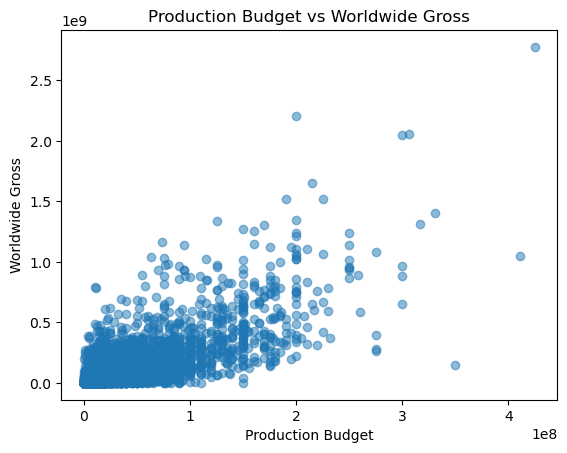

In [94]:

# production budget vs worldwide gross scatter plot
x=c_numbers["production_budget"]
y=c_numbers["worldwide_gross"]
plt.scatter(x, y, alpha=0.5)
plt.title("Production Budget vs Worldwide Gross")
plt.figsize=(10, 5)
plt.xlabel("Production Budget")
plt.ylabel("Worldwide Gross")
plt.show()


The scatter plot demonstrates a strong positive correlation between production budgets and worldwide gross revenue. As the initial investment increases, the potential for higher global returns generally rises, though the density of the data at lower budget levels suggests that significant financial success is still possible for smaller productions.

Several outliers are visible in the top-right quadrant, representing films with budgets exceeding $400 million that yielded massive returns. Conversely, the spread of data points indicates that high spending does not always guarantee a proportional increase in revenue, emphasizing the inherent risk in high-budget filmmaking.

#### 8. Average ROI by Budget Range

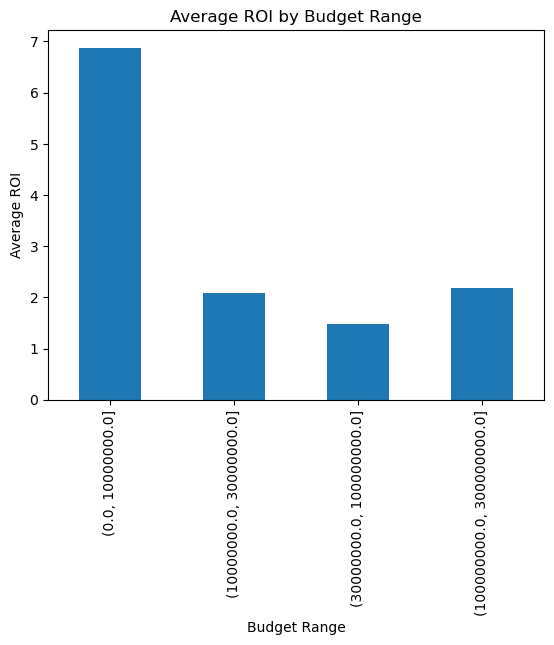

In [95]:
numbers['roi'] = (numbers['worldwide_gross'] - numbers['production_budget']) / numbers['production_budget']


numbers['budget_bin'] = pd.cut(
    numbers['production_budget'],
    bins=[0, 10e6, 30e6, 100e6, 300e6]
)

budget_roi = numbers.groupby('budget_bin')['roi'].mean()

plt.figure()
budget_roi.plot(kind='bar')
plt.title('Average ROI by Budget Range')
plt.xlabel('Budget Range')
plt.ylabel('Average ROI')
plt.show()

The range between 0 and 10M(low budget) has a higher average return on investment as compared to other budget ranges. However, movies with a high budget range gives a high return on investment though not guaranteed.

### IMDB dataset Visuals

#### 9. Top Performing Movie Genres by Average Rating

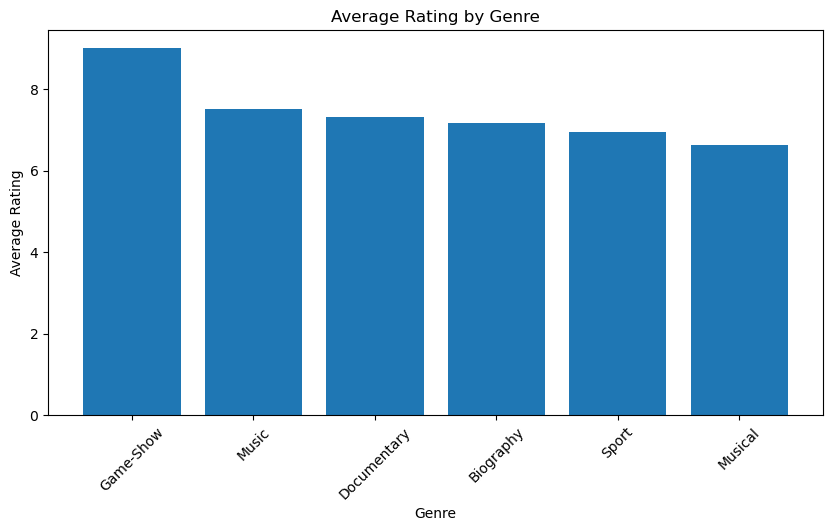

In [96]:
# Finding the top 6 genres with highest average ratings
avg_rating_genre = (
    c_imdb.groupby("genres")["averagerating"]
    .mean()
    .sort_values(ascending=False)
    .head(6)
)
# Visualizing average rating by genre using a bar plot
plt.figure(figsize=(10,5))
plt.bar(avg_rating_genre.index, avg_rating_genre.values)
plt.title("Average Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()




The bar chart reveals that Game-Show, Music, and Documentary are the highest-rated genres in the dataset. Specifically, Game-Show leads significantly with an average rating of 9.0, while the other top categories maintain strong scores between 6.6 and 7.5.

While Drama may be the most common genre produced, investing in these high-rated categories could lead to better critical reception and a more loyal audience base.

#### 10. Runtime per movie count

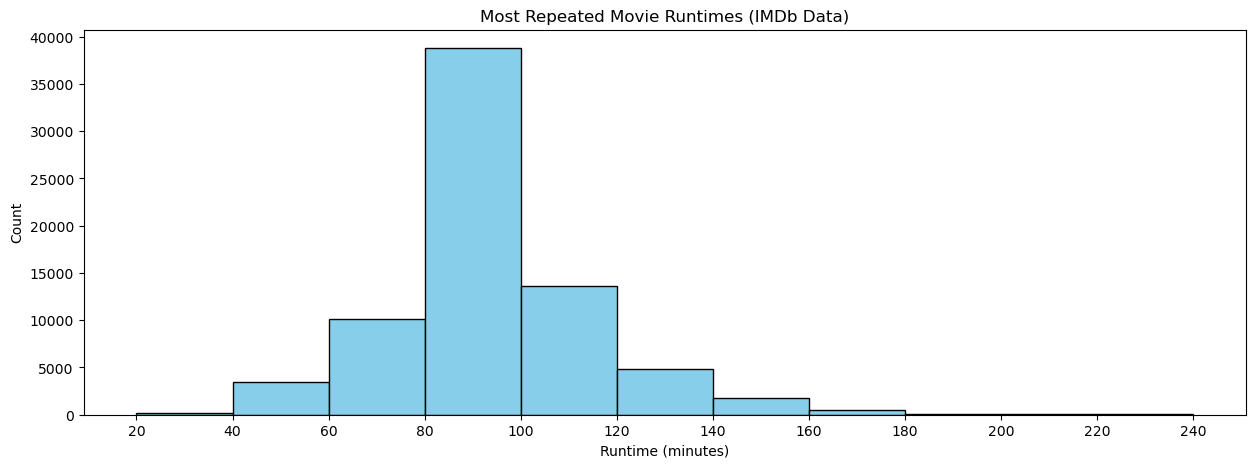

In [97]:
# creating bins for runtime minutes
bins = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240]

plt.figure(figsize=(15, 5))  # Corrected from plt.figsize=(15, 5)
plt.hist(c_imdb['runtime_minutes'], bins=bins, color='skyblue', edgecolor='black')

plt.xticks(bins)
plt.title('Most Repeated Movie Runtimes (IMDb Data)')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Count')
plt.show()


The bar chart shows that most movies have a runtime of between 80 and 100 minutes. This range proves significant since the mean of runtime minutes is 95 and this falls in the range(80-100).

#### 11. Average Rating by Release Month

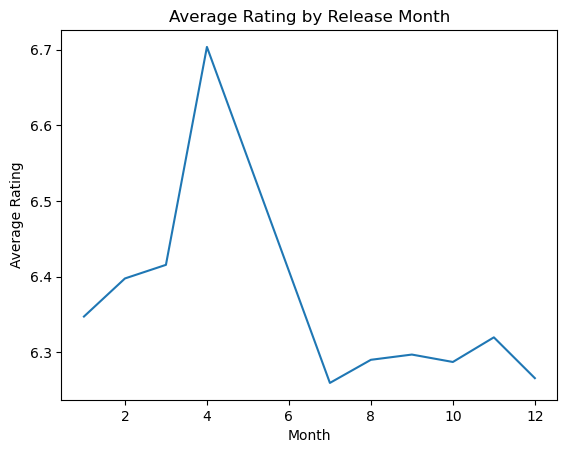

In [98]:
c_imdb['release_month'] = c_imdb['start_year'] % 12 + 1
month_rating = c_imdb.groupby('release_month')['averagerating'].mean()

plt.figure()
month_rating.plot()
plt.title('Average Rating by Release Month')
plt.xlabel('Month')
plt.ylabel('Average Rating')
plt.show()

The highest rating falls on the fourth month(April) which lies in Q2. After April there is a sharp decline leading to a lower rating in Q3(July, August and September).

#### 12. Number of movies released per month

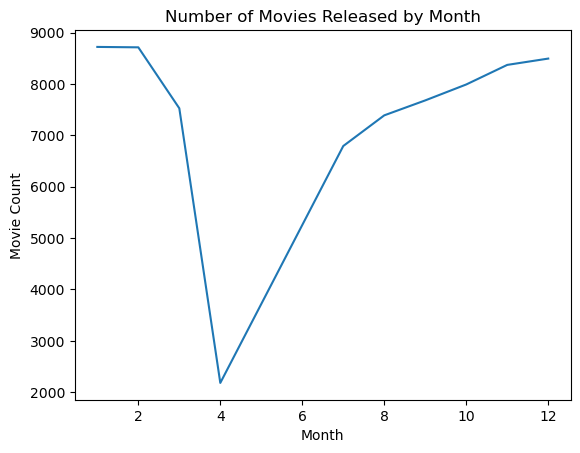

In [99]:
# Analyzing number of movies released by month
month_count = c_imdb['release_month'].value_counts().sort_index()

plt.figure()
month_count.plot()
plt.title('Number of Movies Released by Month')
plt.xlabel('Month')
plt.ylabel('Movie Count')
plt.show()

The visual shows that in the first quarter(Q1) the number of movies released is high, then there is a sharp decline in the second quarter(Q2), where the number of movies released is very low. After there is a continous increase in the numbers of movies released in both Q3 and Q4. There is a peak in the last quarter moving to the first quarter.

### Box Office Dataset Visuals

#### 13. Box Office Revenue Over the Years by Studio

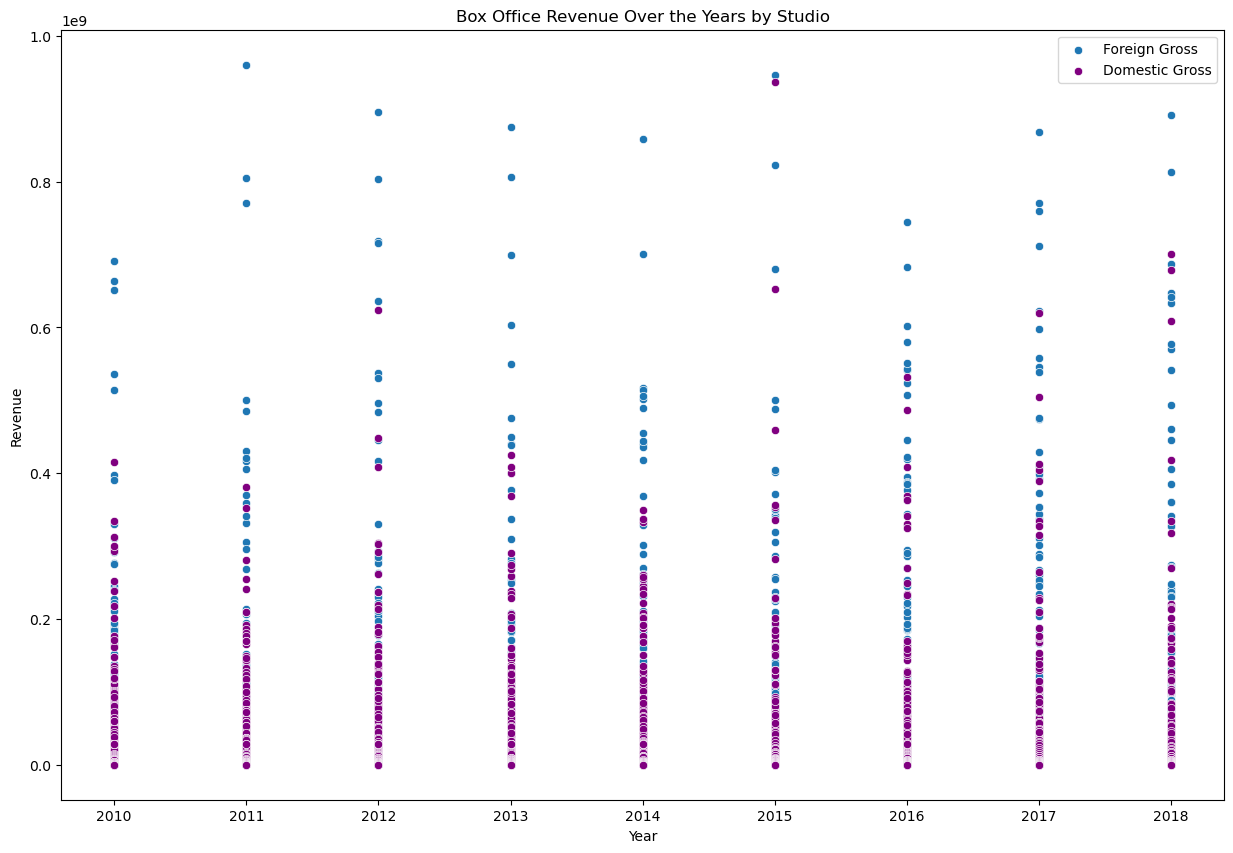

In [100]:
# Checking which studio dominated the box office in terms of revenue
# aggregating the domestic and foreign gross by studio
studio_revenue= c_box_office.groupby('studio')[['domestic_gross', 'foreign_gross']].sum()

#select the top 10 studios
top_studios= studio_revenue.sort_values('domestic_gross', ascending =False).head(30)


plt.figure(figsize=(15, 10))
sns.scatterplot(x='year', y='foreign_gross', data=c_box_office, label='Foreign Gross')
sns.scatterplot(x='year', y='domestic_gross', data=c_box_office, color='purple', label='Domestic Gross')
plt.title('Box Office Revenue Over the Years by Studio')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.legend()                  
plt.show()

From the above, we can see that the foreign gross often exceeds the domestic gross. Both markets have outliers, but the international market has a high baseline of success in films compared to the domestic market.

#### 14. Top Studios by Domestic and Foreign Gross

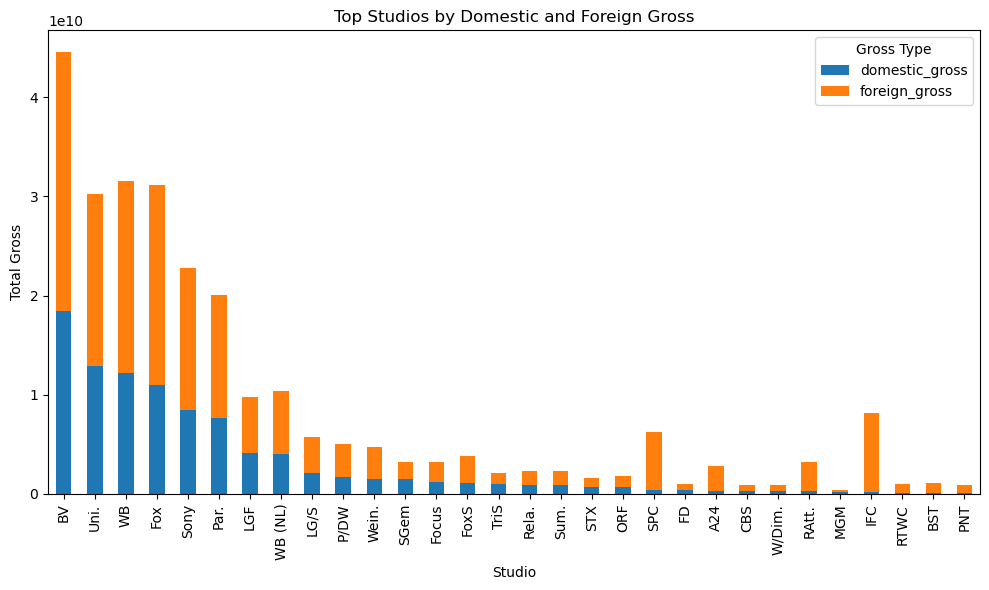

In [101]:
# Plotting the top studios by domestic and foreign revenue
top_studios.plot(kind='bar', figsize=(10,6), stacked=True)

plt.title('Top Studios by Domestic and Foreign Gross')
plt.xlabel('Studio')
plt.ylabel('Total Gross')
plt.xticks(rotation=90)
plt.legend(title='Gross Type')
plt.tight_layout()
plt.show()


From the above, Bv studio has the highest total gross followed by WB, Fox then Uni. Which means that they are the top performing studios in terms of production. 